# Notebook 08 — Detección de trayectorias con YOLO (Etapa 1)

## Idea

Primera etapa del pipeline _detect-then-segment_ de `plan/detection-segmentation-guide.md`:
un detector localiza cada traza del kymógrafo como una **caja**. Se comparan dos detectores
sobre el mismo dataset exportado por `src/axonal_tracking/etiquetas_deteccion.py`:

1. **Baseline clásico** (sin aprendizaje): umbral + componentes conexas (guía §4.2). Es el
   piso que YOLO debe superar (requisito 5.4: comparación clásico-vs-ML).
2. **YOLO fine-tuneado** `yolov8n` (guía §4.3).

**Dos clases**: `movil` (0) y `estatico` (1). Este notebook prueba la variante _con_ estáticas
para ver cómo se comporta; para movers-only, re-exportar con `etiquetar_estaticos=False` y
volver a correr (ver la discusión sobre etiquetar estáticas vs. tratarlas como fondo). **Mirar
las métricas por clase**, no sólo el mAP global: si `estatico` sale ruidosa, es la señal.

Requisitos: correr `scripts/exportar_etiquetas_deteccion.py` antes (genera `kymograph_detection.yaml`).


---

## 0. Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import yaml

sys.path.append(str(Path("..") / "src"))
from axonal_tracking import etiquetas_deteccion as ed

RAIZ = Path("..").resolve()
DATASETS = RAIZ / "datasets"
YOLO_DIR = DATASETS / "yolo_detection"
DATA_YAML = YOLO_DIR / "kymograph_detection.yaml"

assert (
    DATA_YAML.exists()
), f"No existe {DATA_YAML}. Correr scripts/exportar_etiquetas_deteccion.py primero."
print("data-config:", DATA_YAML)
print(yaml.safe_load(DATA_YAML.read_text()))

data-config: /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/kymograph_detection.yaml
{'path': '/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'movil', 1: 'estatico'}}


---

## 1. Baseline clásico — umbral + componentes conexas (guía §4.2)

Detector **sin aprendizaje**: se binariza el kymógrafo por umbral, se conectan los píxeles
brillantes con un cierre morfológico, y cada componente conexa da una caja candidata. Es
agnóstico a clase (sólo dice "acá hay una traza"), y sirve de piso: si YOLO no le gana, algo
está mal antes de la Etapa 2. Se evalúa con recall/precision/F-beta (beta>1 pondera recall,
mismo criterio que `roi_detect.py` de synthkymo).


In [2]:
from skimage.filters import threshold_otsu
from skimage.morphology import closing, disk
from skimage.measure import label, regionprops


def detectar_clasico(kymo, cierre_radio=1, area_min=12):
    """Baseline sin aprendizaje: umbral de Otsu (adaptativo por imagen) + componentes
    conexas -> cajas (x1, y1, x2, y2), agnóstico a clase. Es el piso que YOLO debe superar
    (guía §4.2). Otsu se banca la variedad de brillo entre configs; un percentil global no.
    """
    a = np.asarray(kymo, dtype=float)
    if a.ndim == 3:
        a = a[..., 0]
    mask = closing(a > threshold_otsu(a), disk(cierre_radio))
    cajas = []
    for r in regionprops(label(mask)):
        if r.area < area_min:
            continue
        minr, minc, maxr, maxc = r.bbox
        cajas.append((float(minc), float(minr), float(maxc), float(maxr)))
    return cajas


def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(ix2 - ix1, 0.0) * max(iy2 - iy1, 0.0)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def evaluar_deteccion(pred, gt, iou_thr=0.3, beta=2.0):
    """recall/precision/F-beta por matching greedy de cajas predichas a GT por IoU."""
    matched = set()
    tp = 0
    for p in pred:
        mejor_j, mejor_iou = -1, iou_thr
        for j, g in enumerate(gt):
            if j in matched:
                continue
            v = iou(p, g)
            if v >= mejor_iou:
                mejor_j, mejor_iou = j, v
        if mejor_j >= 0:
            matched.add(mejor_j)
            tp += 1
    recall = tp / max(len(gt), 1)
    precision = tp / max(len(pred), 1)
    fb = (1 + beta**2) * precision * recall / max(beta**2 * precision + recall, 1e-9)
    return {
        "recall": recall,
        "precision": precision,
        "f_beta": fb,
        "n_pred": len(pred),
        "n_gt": len(gt),
    }

In [3]:
MIN_DESPLAZAMIENTO_PX = (
    8.0  # umbral movil/estatico del laboratorio: 0.872um / 0.107um/px
)
# ~= 8.15px (docs/handover.md SS2.3) -- DEBE ser el mismo valor usado al exportar
# (scripts/exportar_etiquetas_deteccion.py --min-desplazamiento-px 8), si no la evaluacion
# de aca abajo mide contra un ground truth distinto del que YOLO realmente vio en las etiquetas.


def gt_cajas(
    kymo, positions, pixel_scale_um, min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX
):
    """Cajas ground-truth (ambas clases) de una escena, reusando el exportador."""
    T, L = np.asarray(kymo).shape[:2]
    return [
        (c.x1, c.y1, c.x2, c.y2)
        for c in ed.cajas_desde_positions(
            positions,
            pixel_scale_um,
            (T, L),
            min_desplazamiento_px=min_desplazamiento_px,
        )
    ]


filas = []
for s in sorted((DATASETS / "test").glob("sample_*")):
    kymo = ed._leer_kymografo_tif(s / "kymograph.tif")
    positions = pd.read_csv(s / "positions.csv")
    px = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )
    filas.append(
        evaluar_deteccion(detectar_clasico(kymo), gt_cajas(kymo, positions, px))
    )

clasico = pd.DataFrame(filas)
print("Baseline clásico sobre test (media):")
print(clasico[["recall", "precision", "f_beta"]].mean().round(3).to_string())

Baseline clásico sobre test (media):
recall       0.484
precision    0.458
f_beta       0.461


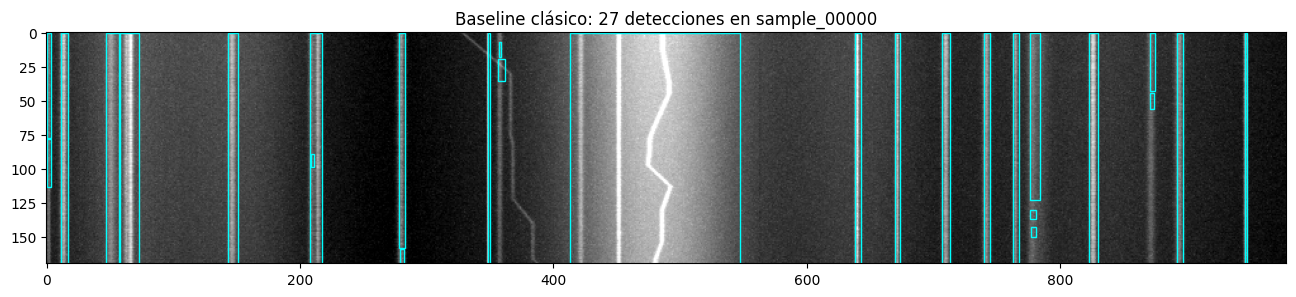

In [4]:
# inspección cualitativa: cajas del baseline sobre una muestra
s = sorted((DATASETS / "test").glob("sample_*"))[0]
kymo = np.asarray(ed._leer_kymografo_tif(s / "kymograph.tif"))
if kymo.ndim == 3:
    kymo = kymo[..., 0]
pred = detectar_clasico(kymo)

fig, ax = plt.subplots(figsize=(16, 3))
ax.imshow(
    kymo,
    cmap="gray",
    aspect="auto",
    vmin=np.percentile(kymo, 1),
    vmax=np.percentile(kymo, 99.5),
)
for x1, y1, x2, y2 in pred:
    ax.add_patch(
        Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="cyan", facecolor="none", lw=1)
    )
ax.set_title(f"Baseline clásico: {len(pred)} detecciones en {s.name}")
plt.show()

---

## 2. Fine-tune YOLO `yolov8n` (guía §4.3)

`yolov8n` = variante "nano", la más chica: los kymógrafos son de baja complejidad visual y
pocas clases, así que un backbone grande cuesta presupuesto sin ganar mucho.

**`imgsz=1536` (subido desde 960) -- la sección 3.1 ya dio la respuesta que faltaba.** Con
`imgsz=960`/`rect=True`, el recall de `movil` se derrumbaba de 0.89 a 0.03 a 0.00 apenas se
cruza ~15:1 de aspect ratio -- invisible en el mAP agregado porque las muestras "normales"
(<8:1, 84% del test) lo dominan. La causa es aritmética: `rect=True` escala el lado largo a
`imgsz` y el corto por el mismo factor, así que la altura post-resize es `imgsz / AR`. A
`imgsz=960`, AR=31 da ~31px de alto -- casi nada de la pendiente (la señal móvil/estático)
sobrevive. A `imgsz=1536`, ese mismo caso da ~50px, un poco por debajo de donde el recall ya
funcionaba bien (bucket 8-15:1). No es una garantía -- es el experimento barato antes de
invertir en tiling (cortar cada kymógrafo ancho en tiles que conservan el eje temporal
completo). Repetir la sección 3.1 después de este entrenamiento es lo que decide si alcanza.

Correr en GPU si se puede; con `epochs=100` en CPU/MPS puede tardar -- bajar `epochs` para una
prueba rápida. A `imgsz=1536` (2.56x más píxeles que 960) el entrenamiento tarda más y usa más
memoria que la corrida anterior (0.78h a 960) -- si `batch=16` da error de memoria en MPS,
bajarlo a 8.

**Nota**: el run escribe pesos/plots en `results/yolo/` -- conviene agregar `results/` al
`.gitignore` si no está.


In [5]:
from ultralytics import YOLO

modelo = YOLO("yolov8n.pt")  # checkpoint COCO preentrenado

In [6]:
resultados = modelo.train(
    data=str(DATA_YAML),
    epochs=100,  # bajar para prueba rápida
    imgsz=1536,  # subido desde 960 (SS3.1: recall se derrumbaba arriba de 15:1 AR --
    # hipotesis: altura post-resize = imgsz/AR quedaba demasiado chica para ver la pendiente)
    rect=True,  # batches rectangulares (menos padding en imagenes no cuadradas)
    batch=16,
    patience=20,  # early stopping si val no mejora
    project=str(RAIZ / "results" / "yolo"),
    name="deteccion_v1",
    device="mps",  # descomentar/forzar si hace falta (Mac); si no, autodetecta
)
print("mejor modelo:", resultados.save_dir)

New https://pypi.org/project/ultralytics/8.4.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.101 🚀 Python-3.13.2 torch-2.12.0 MPS (Apple M5 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/kymograph_detection.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1536, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup

---

## 3. Evaluar — mAP global y **por clase** (guía §4.4)

Lo importante acá no es sólo el mAP global sino la separación **`movil` vs `estatico`**: si
`estatico` sale mucho peor que `movil`, es la inconsistencia de etiquetar estáticas GT mientras
los artefactos estáticos quedan como fondo (misma pinta, etiqueta opuesta) -> señal para probar
la variante movers-only.


In [7]:
metricas = modelo.val(data=str(DATA_YAML), split="test", imgsz=1536)
print("mAP50-95:", round(float(metricas.box.map), 3))
print("mAP50   :", round(float(metricas.box.map50), 3))
print("por clase (mAP50-95):")
for i, ap in zip(
    metricas.box.ap_class_index, metricas.box.maps[metricas.box.ap_class_index]
):
    print(f"  {modelo.names[int(i)]:10s}: {float(ap):.3f}")

Ultralytics 8.4.101 🚀 Python-3.13.2 torch-2.12.0 CPU (Apple M5 Pro)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 1150.4±465.1 MB/s, size: 274.5 KB)
val: Scanning /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/labels/test.cache... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 419.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.3s/it 56.8s3.2ss
                   all        400      11000      0.818      0.729      0.823      0.564
                 movil        395       2265       0.77      0.752      0.832      0.594
              estatico        400       8735      0.867      0.705      0.814      0.533
Speed: 0.2ms preprocess, 134.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/runs/de

### 3.1 Recall estratificado por aspect ratio -- la pregunta que decide si `imgsz` hace falta tocar

`modelo.val()` da un número agregado; no dice si ese número esconde una caída fuerte justo en
las muestras más anchas, que es exactamente donde `rect=True` comprime más el eje temporal
antes de que la red vea la imagen (`docs/handover.md` §2.1). Buckets de aspect ratio (posición
`L` / tiempo `T`) alineados a los percentiles reales (`p50`=7.1:1, `p90`=12.1:1, `p99`=19.1:1):
`<8:1`, `8-15:1`, `15-25:1`, `>25:1`.

Se predice de a **una imagen por vez** (mismo motivo documentado más abajo: batchear anchos
distintos distorsiona las más angostas) y se empareja contra el ground truth con la misma
`evaluar_deteccion`/`iou` de la sección 1 -- así el criterio de matching es idéntico al del
baseline clásico, sólo cambia el detector. Se reporta `recall` clase-agnóstico (comparable con
el baseline clásico de la sección 1) y `recall` sólo de la clase `movil`, que es la que
`docs/handover.md` §2.2 marca como la que realmente importa.


In [8]:
def bucket_ar(ar):
    if ar < 8:
        return "<8:1"
    if ar < 15:
        return "8-15:1"
    if ar < 25:
        return "15-25:1"
    return ">25:1"


ORDEN_BUCKETS = ["<8:1", "8-15:1", "15-25:1", ">25:1"]

filas_ar = []
for s in sorted((DATASETS / "test").glob("sample_*")):
    img_path = YOLO_DIR / "images" / "test" / f"{s.name}.png"
    if not img_path.exists():
        continue

    kymo = np.asarray(ed._leer_kymografo_tif(s / "kymograph.tif"))
    if kymo.ndim == 3:
        kymo = kymo[..., 0]
    T, L = kymo.shape
    positions = pd.read_csv(s / "positions.csv")
    px = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )

    cajas_gt = ed.cajas_desde_positions(
        positions, px, (T, L), min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX
    )
    gt_todas = [(c.x1, c.y1, c.x2, c.y2) for c in cajas_gt]
    gt_movil = [(c.x1, c.y1, c.x2, c.y2) for c in cajas_gt if c.clase == ed.CLASE_MOVIL]

    # una imagen por vez -- ver la nota en la inspeccion cualitativa mas abajo sobre por que
    r = modelo.predict(str(img_path), imgsz=1536, conf=0.25, verbose=False)[0]
    boxes_xyxy = r.boxes.xyxy.cpu().numpy()
    boxes_cls = r.boxes.cls.cpu().numpy()
    pred_todas = [tuple(b) for b in boxes_xyxy]
    pred_movil = [
        tuple(b) for b, c in zip(boxes_xyxy, boxes_cls) if int(c) == ed.CLASE_MOVIL
    ]

    m_todas = evaluar_deteccion(pred_todas, gt_todas)
    m_movil = evaluar_deteccion(pred_movil, gt_movil)
    filas_ar.append(
        {
            "muestra": s.name,
            "aspect_ratio": L / T,
            "bucket": bucket_ar(L / T),
            "recall_todas": m_todas["recall"],
            "recall_movil": m_movil["recall"],
            "n_gt_movil": m_movil["n_gt"],
        }
    )

ar_df = pd.DataFrame(filas_ar)
print(f"{len(ar_df)} muestras de test evaluadas")
ar_df.groupby("bucket").agg(
    n_muestras=("muestra", "count"),
    recall_todas=("recall_todas", "mean"),
    recall_movil=("recall_movil", "mean"),
    n_gt_movil=("n_gt_movil", "sum"),
).round(3).reindex(ORDEN_BUCKETS)

400 muestras de test evaluadas


,n_muestras,recall_todas,recall_movil,n_gt_movil
bucket,,,,
<8:1,279,0.806,0.772,1403
8-15:1,58,0.836,0.971,340
15-25:1,48,0.720,0.815,386
>25:1,15,0.000,0.000,136


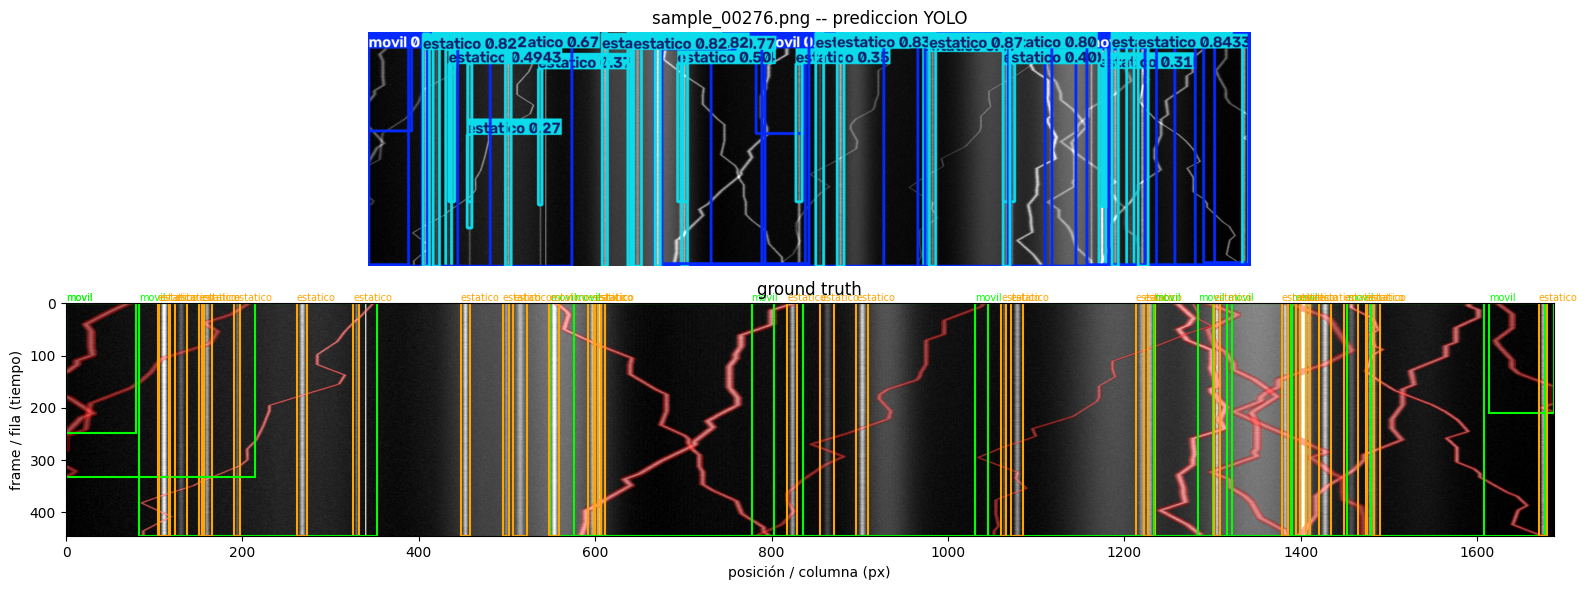

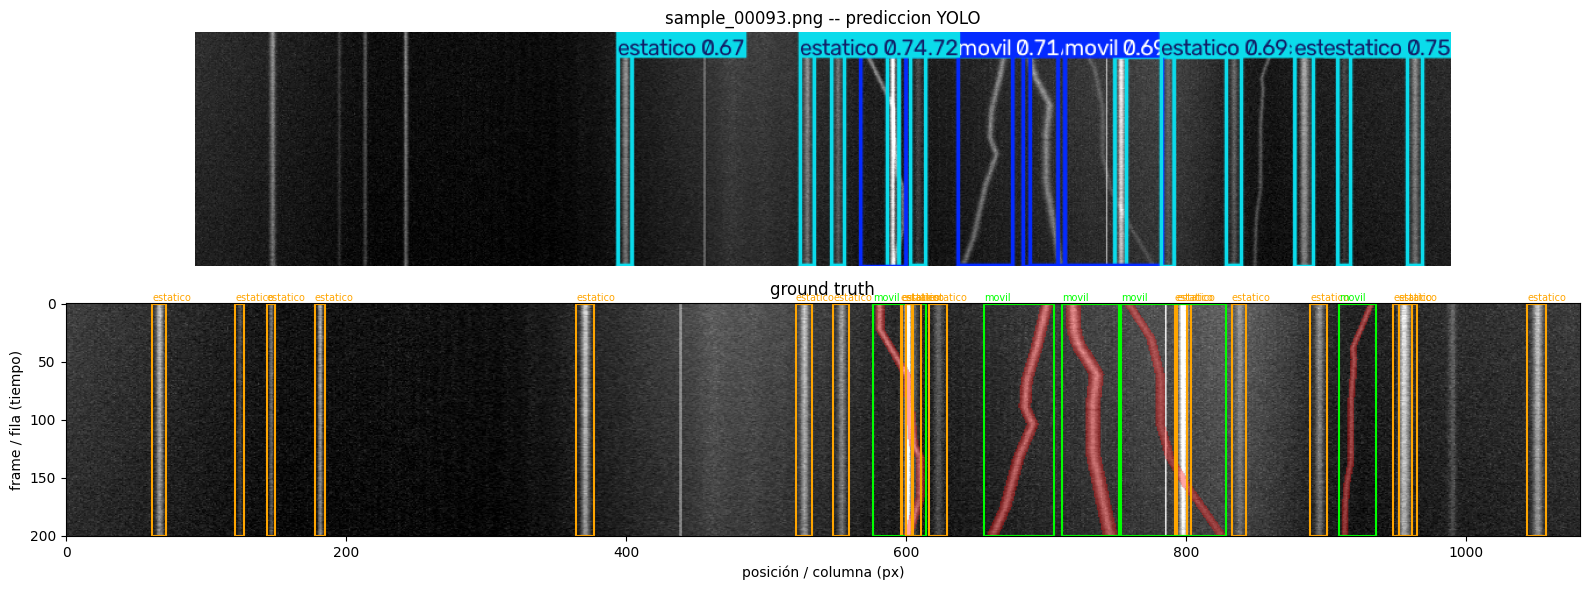

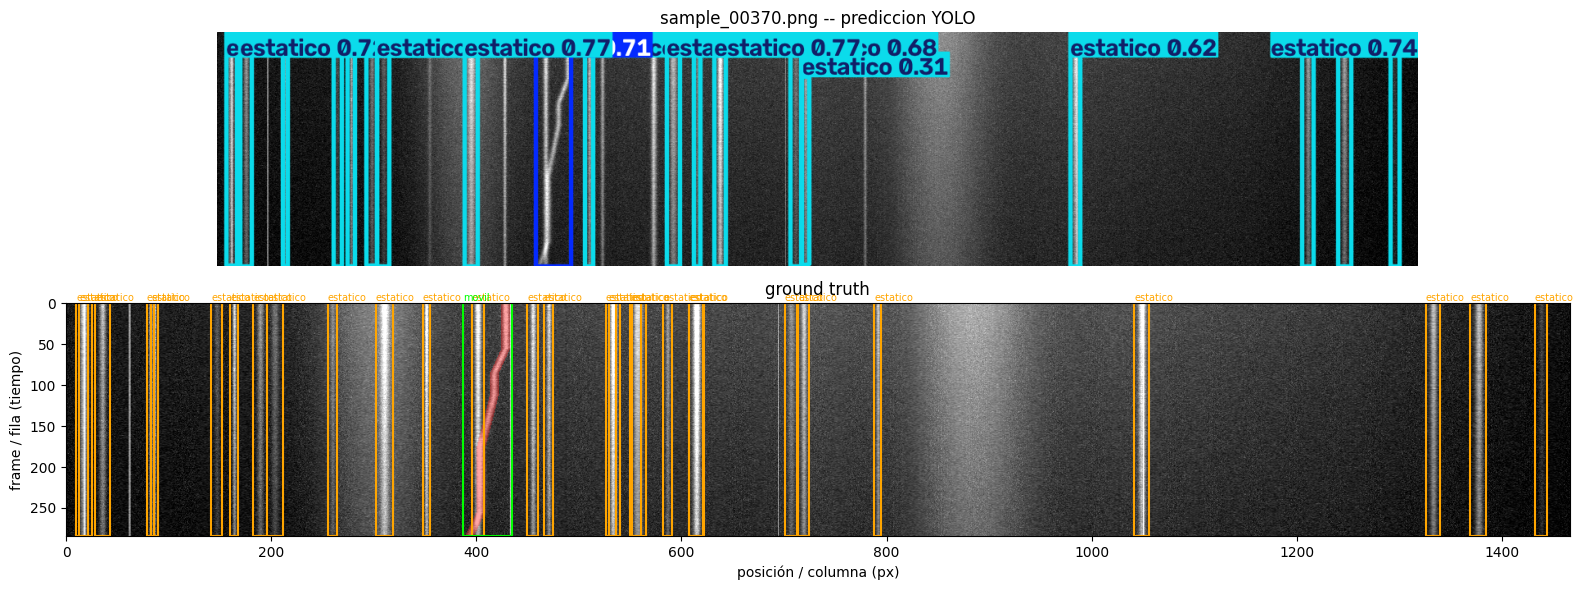

In [9]:
# inferencia cualitativa: prediccion (arriba) vs. ground truth (abajo), por muestra
import random

test_imgs = sorted((YOLO_DIR / "images" / "test").glob("*.png"))
muestras = random.sample(test_imgs, min(3, len(test_imgs)))

for ruta in muestras:
    # OJO: predecir de a UNA imagen, NO pasar la lista completa a predict().
    # Los kymografos tienen anchos muy distintos entre muestras (verificado: 690 a
    # 1453px en este dataset). Si se batchean varias juntas en una sola llamada,
    # ultralytics las redimensiona/rellena a un lienzo compartido -> distorsiona las
    # mas angostas y produce cajas degeneradas (altura ~0px) y basura de baja
    # confianza. Verificado directamente: la misma imagen sola da cajas limpias
    # que calzan con el ground truth; en batch de 3, la misma imagen paso de 6 a
    # 14 cajas "movil", varias con altura 0.
    r = modelo.predict(str(ruta), imgsz=1536, conf=0.25, verbose=False)[0]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6))

    axes[0].imshow(r.plot()[..., ::-1])  # ultralytics devuelve BGR
    axes[0].set_title(f"{ruta.name} -- prediccion YOLO")
    axes[0].axis("off")

    s = DATASETS / "test" / ruta.stem
    kymo = ed._leer_kymografo_tif(s / "kymograph.tif")
    positions = pd.read_csv(s / "positions.csv")
    px = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )
    ed.plot_muestra_anotada(kymo, positions, px, ax=axes[1])
    axes[1].set_title("ground truth")

    plt.tight_layout()
    plt.show()

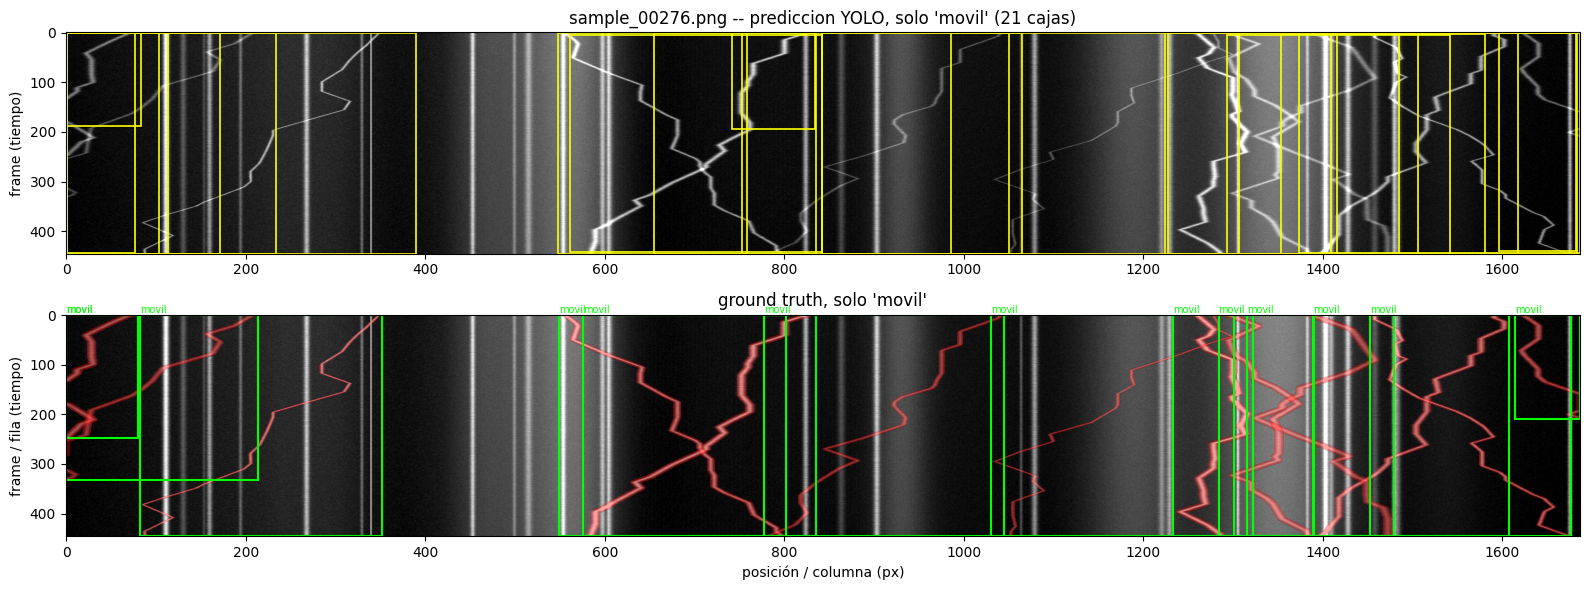

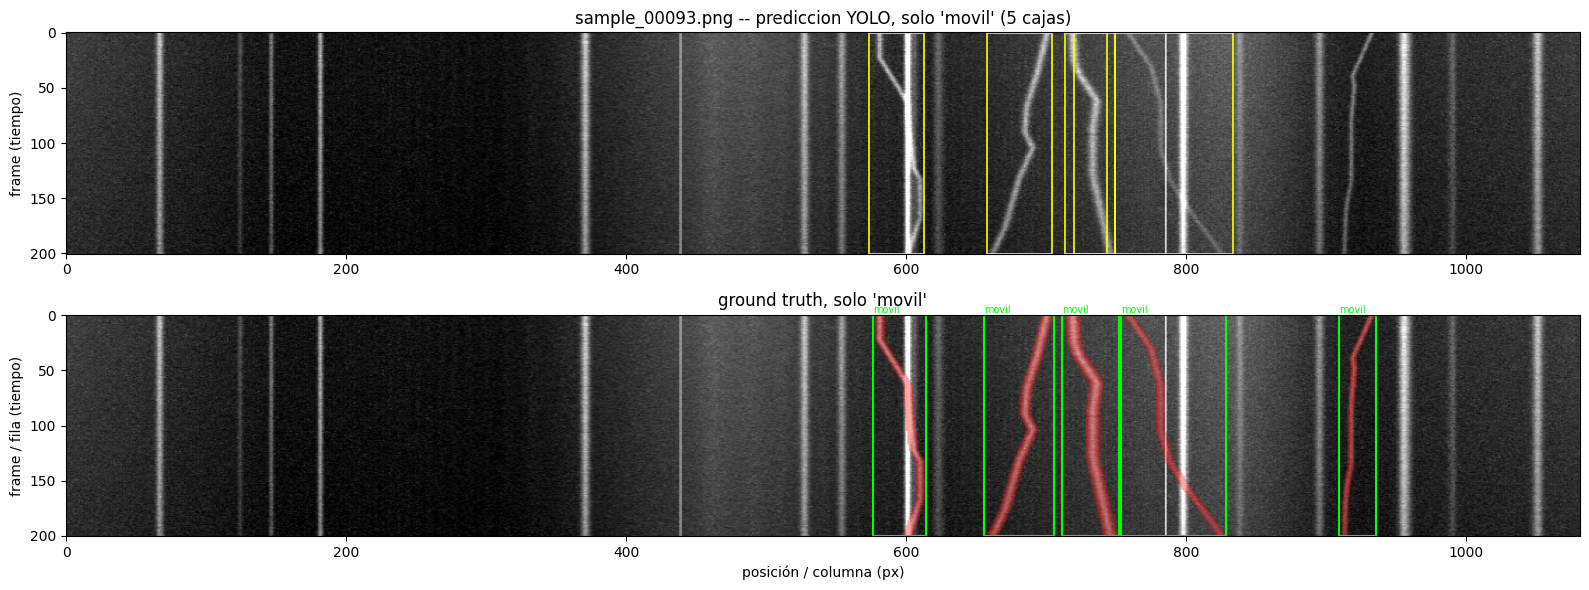

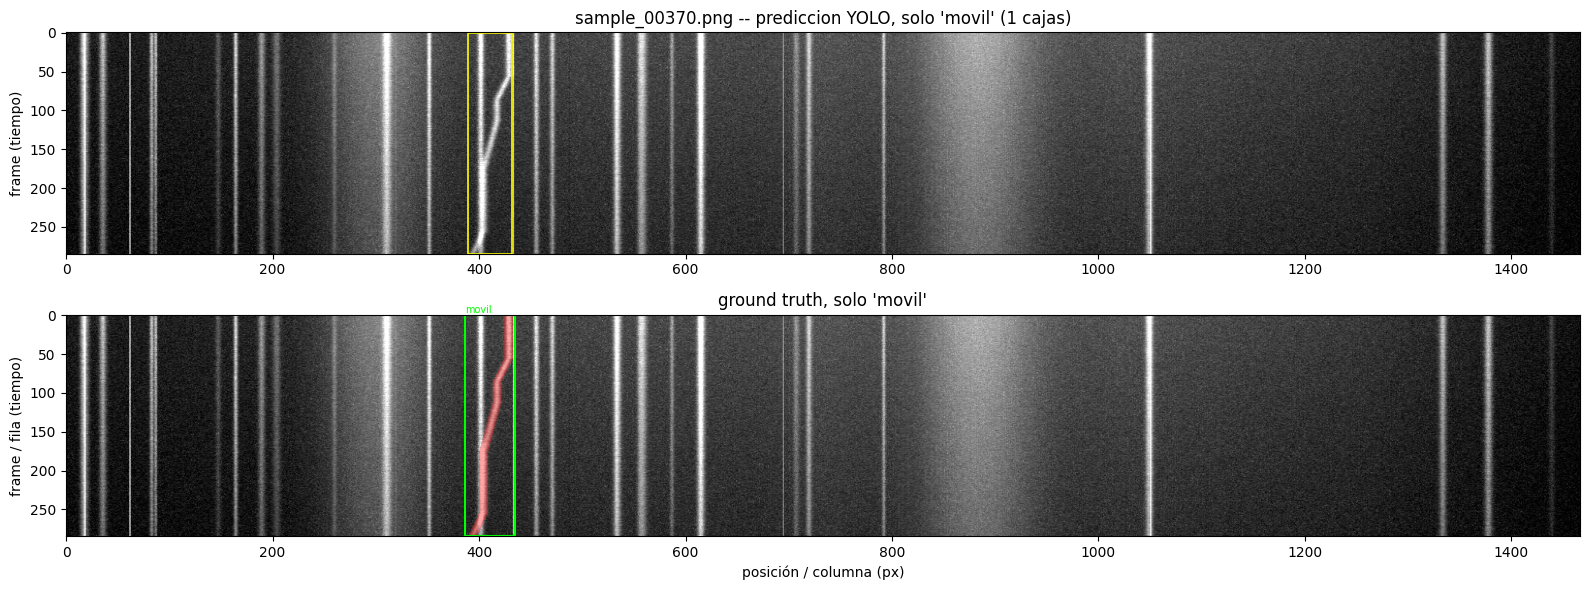

In [10]:
# misma inspeccion que la celda anterior pero SOLO clase movil -- ni la prediccion ni el
# ground truth dibujan cajas de "estatico" aca (reusa las mismas `muestras` de arriba, para
# comparar ambas figuras sobre las mismas imagenes)
for ruta in muestras:
    r = modelo.predict(str(ruta), imgsz=1536, conf=0.25, verbose=False)[0]
    boxes_xyxy = r.boxes.xyxy.cpu().numpy()
    boxes_cls = r.boxes.cls.cpu().numpy()
    cajas_pred_movil = [
        b for b, c in zip(boxes_xyxy, boxes_cls) if int(c) == ed.CLASE_MOVIL
    ]

    s = DATASETS / "test" / ruta.stem
    kymo = np.asarray(ed._leer_kymografo_tif(s / "kymograph.tif"))
    if kymo.ndim == 3:
        kymo = kymo[..., 0]
    positions = pd.read_csv(s / "positions.csv")
    px = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 6))

    axes[0].imshow(
        kymo,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo, 1),
        vmax=np.percentile(kymo, 99.5),
    )
    for x1, y1, x2, y2 in cajas_pred_movil:
        axes[0].add_patch(
            Rectangle(
                (x1, y1), x2 - x1, y2 - y1, edgecolor="yellow", facecolor="none", lw=1.2
            )
        )
    axes[0].set_title(
        f"{ruta.name} -- prediccion YOLO, solo 'movil' ({len(cajas_pred_movil)} cajas)"
    )
    axes[0].set_ylabel("frame (tiempo)")

    ed.plot_muestra_anotada(
        kymo,
        positions,
        px,
        ax=axes[1],
        min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX,
        etiquetar_estaticos=False,
    )
    axes[1].set_title("ground truth, solo 'movil'")

    plt.tight_layout()
    plt.show()

---

## 4. Comparación clásico vs. YOLO + conclusión

- Tabla clásico vs. YOLO (recall/precision/F-beta y mAP) sobre el **mismo** test.
- Cualitativo: dónde falla cada uno (trazas tenues, cruces, densidad) -- el "por qué" importa
  tanto como el número (requisito 5.4).
- Decisión pendiente: **¿dos clases o movers-only?** Este notebook corre la variante de 2
  clases; para la comparación honesta, re-exportar con `etiquetar_estaticos=False`, re-entrenar,
  y comparar la detección de **`movil`** entre ambas (mismo detector, mismas imágenes, sólo
  cambian las etiquetas).
